# Do the suite's numbers add up the way Anand's analyst will add them?

**Week 2, Monday. Chapter 5 of 6.** Chapters 1 to 4 built every number the Monday suite
reports; this chapter adds them up the way an auditor does, before the auditor does.

> "My analyst will add your rows before reading a single query. If they do not add up, the
> suite does not reach me."
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand's analyst audits the Monday suite, and the first thing an
auditor does is add: the segments against the book, the two quarters against the half-year. A
half-year line that shows more Retail-Plus customers than the tier has members fails the audit
on sight, and every other number in the suite is doubted with it. The head of Retail-Plus would
read that every member was active and never see the members who bought nothing all half-year.

**The questions on the way.**
1. How should the suite produce its half-year column?
2. Do the segments add back to the book in each quarter?
3. How many Retail-Plus customers bought in the half-year?
4. Does the overlap between the two quarters explain the gap?

**The metric at stake.** Customers who bought in a window, each counted once, for each quarter
and for the half-year, April to September 2026; and the tie-outs, the sums an auditor checks.
Orders and booked revenue come along in every line.

**What chapters 3 and 4 found.** Retail-Plus had 91 customers in Q1 and 76 in Q2, and its
revenue fell 29.4 percent, from Rs 5,85,770 to Rs 4,13,380; its spend per member fell 29.4
percent once both averages covered the same members. The tier holds 120 members on Kalpa's
customer table.

**A real company with the same question.** Meta reports its daily active people across
Facebook, Instagram, Messenger and WhatsApp: 3.58 billion on average in December 2025. Its
annual report defines a daily active person as a logged-in user "who visited at least one of
these Family products" that day, and says it matches accounts to people, "counting such group
of accounts as one person" (Meta Platforms, Form 10-K for 2025). A person who opens two of the
apps is one person, and adding each app's daily users would count them twice.

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D01_05_does_it_add_up_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements with its comment lines removed, for a block that runs several."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def show(rows, caption="", money=(), limit=12):
    """Rows from kit.sql as the kit's table, with the columns named in money set in rupees."""
    if not rows:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(rows[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12):
    """Print a named block, run it, show its rows and hand them back."""
    print(Q[name])
    rows = kit.sql(Q[name])
    show(rows, caption, money, limit)
    return rows

def pct(before, after):
    """The change from before to after, in percent."""
    return 100 * (float(after) - float(before)) / float(before)

Q = blocks("05_does_it_add_up")
print(len(Q), "named queries read from", "C2_W02_D01_05_does_it_add_up_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

7 named queries read from C2_W02_D01_05_does_it_add_up_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


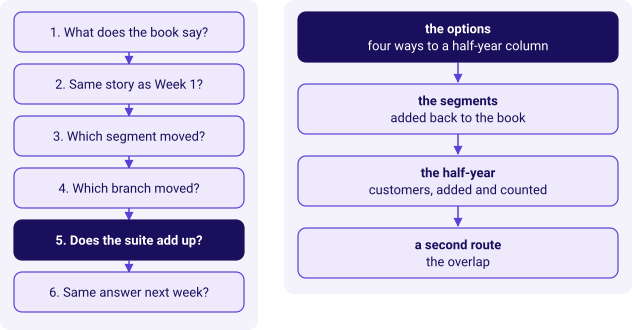

In [2]:
kit.side_by_side(
    kit.ladder(['What does the book say?', 'Same story as Week 1?', 'Which segment moved?', 'Which branch moved?', 'Does the suite add up?', 'Same answer next week?'], lit=4, show=False),
    kit.vflow(['the options\nfour ways to a half-year column', 'the segments\nadded back to the book', 'the half-year\ncustomers, added and counted', 'a second route\nthe overlap'], lit=0, show=False),
)

## The options: how should the suite produce its half-year column?

Anand's sheet shows Q1, Q2 and the half-year for every segment. The quarter rows already exist,
so there is more than one way to reach the half-year:

| Option | What it reads | What it assumes | What the analyst audits |
|---|---|---|---|
| A. Add each segment's two quarter rows in a last step | The 8 quarter rows | That every measure adds across the quarters | One more step, a `sum` |
| B. Count the half-year from the orders, like each quarter | All 1,000 order rows again | Nothing new: the same definition, a wider window | The same query as the quarters, without the quarter |
| C. `GROUPING SETS`: one query returns the quarter rows and the half-year rows | All 1,000 order rows, once | Nothing new, and one more feature to read | One query, with a `NULL` quarter marking the half-year |
| D. Report the quarters and no half-year | Nothing | That nobody wants the half-year | Nothing, until the analyst adds the two quarters by hand |

**Predict before you run.** Option A reads 8 rows and option B reads 1,000. Why might a team
still read the 1,000?

- a) Because Postgres cannot add rows from a CTE.
- b) So that every number in the half-year column comes from its own window, the way each
  quarter's does.
- c) Because 1,000 rows are faster to read than 8.
- d) Because option A cannot add rupees.

-- The suite's middle table: the leaves for each segment and quarter.
SELECT c.segment,
       o.quarter,
       count(*)                      AS orders,
       count(DISTINCT o.customer_id) AS customers,
       sum(o.amount)                 AS revenue
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
ORDER  BY c.segment, o.quarter;


segment,quarter,orders,customers,revenue
Business,Q1,97,36,"Rs 9,90,14,440"
Business,Q2,91,35,"Rs 9,75,84,600"
Retail-Core,Q1,199,102,"Rs 3,73,070"
Retail-Core,Q2,193,96,"Rs 3,66,250"
Retail-Plus,Q1,215,91,"Rs 5,85,770"
Retail-Plus,Q2,140,76,"Rs 4,13,380"
Student,Q1,27,15,"Rs 26,720"
Student,Q2,38,20,"Rs 35,770"


option,rows it reads for the half-year column
A. add the quarter rows,8
B. count from the orders,"1,000"
C. GROUPING SETS,"1,000, once for both columns"
D. no half-year,0


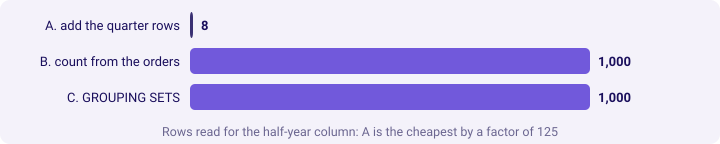

In [3]:
per_q = run("c5_per_quarter", "The suite's middle table: every segment and quarter", money=("revenue",))
order_rows = kit.sql("SELECT count(*) AS n FROM orders")[0]["n"]
kit.table(["option", "rows it reads for the half-year column"],
          [("A. add the quarter rows", len(per_q)), ("B. count from the orders", f"{order_rows:,}"),
           ("C. GROUPING SETS", f"{order_rows:,}, once for both columns"), ("D. no half-year", 0)],
          caption="Sized on this warehouse")
kit.bars([("A. add the quarter rows", len(per_q)), ("B. count from the orders", order_rows),
          ("C. GROUPING SETS", order_rows)],
         title="Rows read for the half-year column: A is the cheapest by a factor of 125", lit=(0,))

**What happened.** The answer is b. Option A reads 8 rows where B reads 1,000, and on a book
this size neither costs a noticeable second. What separates them is what each assumes. B counts
the half-year from the orders with the same definition as each quarter, a wider window and
nothing else, so the analyst audits one definition. A assumes that every measure in the quarter
rows can be added.

**The best-fit call.** Option B, the half-year counted from the orders. **What would change the
call:** if Anand wants several windows at once, months and quarters and the half-year, option C
returns them all from one query that reads the book once, and it is worth one more feature for
the analyst to learn.

In [4]:
kit.check("the middle table has one row per segment and quarter", len(per_q) == 8)
kit.check("option B reads every order", order_rows == 1000)

## 1. Do the segments add back to the book in each quarter?

The first tie-out adds the four segment rows of each quarter and sets the sums beside the book's
own totals from chapter 1.

**Predict before you run.** Will the four segments' Q1 customers add up to the book's 244?

- a) Yes, since each customer belongs to exactly one segment.
- b) No, the segments add to more than 244.
- c) No, the segments add to fewer than 244.
- d) Only orders and rupees can be added, never customers.

-- The first tie-out: in each quarter, do the four segments add back to the book?
WITH per_quarter AS (
    SELECT c.segment, o.quarter, count(*) AS orders,
           count(DISTINCT o.customer_id) AS customers, sum(o.amount) AS revenue
    FROM   orders o JOIN customers c USING (customer_id)
    GROUP  BY c.segment, o.quarter
),
segments_added AS (
    SELECT quarter, sum(orders) AS orders, sum(customers) AS customers, sum(revenue) AS revenue
    FROM   per_quarter
    GROUP  BY quarter
),
book AS (
    SELECT quarter, count(*) AS orders, count(DISTINCT customer_id) AS customers,
           sum(amount) AS revenue
    FROM   orders
    GROUP  BY quarter
)
SELECT s.quarter,
       s.orders    AS segments_orders,    b.orders    AS book_orders,
       s.customers AS segments_customers, b.customers AS book_customers,
       s.revenue   AS segments_revenue,   b.revenue   AS book_revenue
FROM   segments_added s
JOIN   book b USING (quarter)
ORDER  BY s.quarter;


quarter,segments_orders,book_orders,segments_customers,book_customers,segments_revenue,book_revenue
Q1,538,538,244,244,"Rs 10,00,00,000","Rs 10,00,00,000"
Q2,462,462,227,227,"Rs 9,84,00,000","Rs 9,84,00,000"


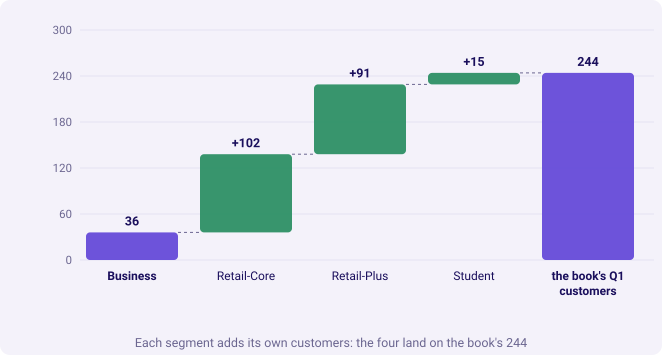

In [5]:
tie = {r["quarter"]: {k: num(v) for k, v in r.items()}
       for r in run("c5_tie_out_segments", "The first tie-out: segments added, beside the book",
                    money=("segments_revenue", "book_revenue"))}
seg_q1 = [(r["segment"], int(r["customers"])) for r in per_q if r["quarter"] == "Q1"]
kit.bridge(seg_q1[0], seg_q1[1:], end_label="the book's Q1 customers", fmt=lambda v: f"{v:,.0f}",
           title="Each segment adds its own customers: the four land on the book's 244")

In [6]:
for q in ("Q1", "Q2"):
    kit.check(f"{q}: the segments' orders, customers and rupees equal the book's",
              (tie[q]["segments_orders"], tie[q]["segments_customers"], tie[q]["segments_revenue"]) ==
              (tie[q]["book_orders"], tie[q]["book_customers"], tie[q]["book_revenue"]),
              f"{tie[q]['segments_customers']} customers")

**What happened.** The answer is a. In each quarter the four segments add back to the book on
orders (538 and 462), on rupees (Rs 10,00,00,000 and Rs 9,84,00,000) and on customers (244 and
227). Customers add across segments because a customer belongs to one segment, so no customer
sits in two of the rows being added.

## 2. How many Retail-Plus customers bought in the half-year?

A hurried analyst builds the half-year the cheap way, option A: the quarter rows are already in a
step, so a last step sums each segment's two rows.

**Predict before you run.** What does the half-year line say for Retail-Plus customers?

- a) 91, the larger quarter.
- b) 107.
- c) 167.
- d) 120, the tier.

In [7]:
added = {r["segment"]: {k: num(v) for k, v in r.items()}
         for r in run("c5_half_year_hurried", "The half-year, the quickest way: two quarter rows added",
                      money=("revenue",))}
p = added["Retail-Plus"]
kit.stats([(str(p["customers"]), "Retail-Plus customers", "the half-year line, added"),
           (str(sum(r["customers"] for r in added.values())), "customers in the book", "the four segments, added"),
           (kit.rupees(round(p["revenue"] / p["customers"])), "revenue per customer", "Retail-Plus half-year, on that count")],
          caption="The hurried half-year line, as it would reach the analyst")

-- The half-year column, the quickest way: add each segment's two quarter rows.
WITH per_quarter AS (
    SELECT c.segment, o.quarter, count(*) AS orders,
           count(DISTINCT o.customer_id) AS customers, sum(o.amount) AS revenue
    FROM   orders o JOIN customers c USING (customer_id)
    GROUP  BY c.segment, o.quarter
)
SELECT segment,
       sum(orders)    AS orders,
       sum(customers) AS customers,
       sum(revenue)   AS revenue
FROM   per_quarter
GROUP  BY segment
ORDER  BY segment;


segment,orders,customers,revenue
Business,188,71,"Rs 19,65,99,040"
Retail-Core,392,198,"Rs 7,39,320"
Retail-Plus,355,167,"Rs 9,99,150"
Student,65,35,"Rs 62,490"


**The plausible wrong answer.** 167 Retail-Plus customers bought in the half-year, and 471 across
the book, so a Retail-Plus customer brought in Rs 5,983 over the six months. The orders (355)
and the rupees (Rs 9,99,150) in the same line are right, which is what makes the customer count
look right beside them.

**Why it is wrong.** A customer who bought in both quarters sits in the Q1 row and in the Q2
row, and adding the rows counts that customer twice. Orders and rupees add across quarters,
because an order belongs to one quarter; customers add only across groups a customer cannot
share, such as segments. The answer the query gave was c.

**The check that exposes it.** A count of customers who bought can never exceed the customers
who exist. Set the half-year line beside each segment's members on the customer table.

-- The check: how many members does each segment hold on the customer table, bought or not?
SELECT segment, count(*) AS members_on_the_book
FROM   customers
GROUP  BY segment
ORDER  BY segment;


segment,members_on_the_book
Business,40
Retail-Core,150
Retail-Plus,120
Student,30


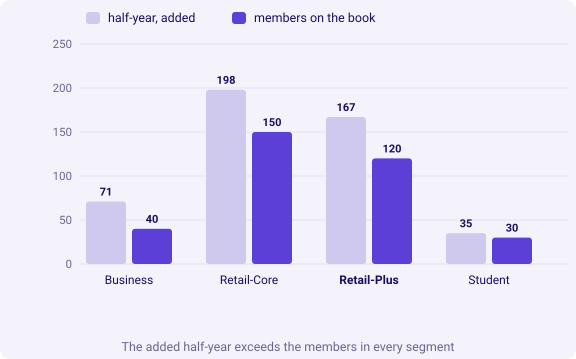

In [8]:
members = {r["segment"]: int(r["members_on_the_book"])
           for r in run("c5_members", "Members per segment on the customer table")}
segs = list(members)
kit.columns(segs, [("half-year, added", [added[s]["customers"] for s in segs]),
                   ("members on the book", [members[s] for s in segs])],
            title="The added half-year exceeds the members in every segment", lit=(2,))

In [9]:
kit.check("the added count exceeds the members in every segment",
          all(added[s]["customers"] > members[s] for s in segs),
          ", ".join(f"{s} {added[s]['customers']} of {members[s]}" for s in segs))
kit.check("Retail-Plus shows 167 customers from a tier of 120", (p["customers"], members["Retail-Plus"]) == (167, 120))
kit.check("the added orders and rupees are right: they equal the book's two quarters",
          sum(r["orders"] for r in added.values()) == 1000 and sum(r["revenue"] for r in added.values()) == 198400000)

**The fix, and what it changed.** Count the half-year's customers from the orders, each counted
once, with the same definition as each quarter and a wider window: option B.

In [10]:
half = {r["segment"]: {k: num(v) for k, v in r.items()}
        for r in run("c5_half_year", "The fix: the half-year counted from the orders", money=("revenue",))}
kit.table(["segment", "added", "counted", "counted twice", "members on the book"],
          [(s, added[s]["customers"], half[s]["customers"], added[s]["customers"] - half[s]["customers"], members[s])
           for s in segs], caption="What the fix changed, segment by segment")
hp = half["Retail-Plus"]
print(f"Retail-Plus revenue per customer over the half-year: {kit.rupees(round(hp['revenue'] / hp['customers']))}, "
      f"not {kit.rupees(round(p['revenue'] / p['customers']))}")

-- The fix: count the half-year's customers from the orders themselves, each counted once.
SELECT c.segment,
       count(*)                      AS orders,
       count(DISTINCT o.customer_id) AS customers,
       sum(o.amount)                 AS revenue
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment
ORDER  BY c.segment;


segment,orders,customers,revenue
Business,188,39,"Rs 19,65,99,040"
Retail-Core,392,131,"Rs 7,39,320"
Retail-Plus,355,107,"Rs 9,99,150"
Student,65,24,"Rs 62,490"


segment,added,counted,counted twice,members on the book
Business,71,39,32,40
Retail-Core,198,131,67,150
Retail-Plus,167,107,60,120
Student,35,24,11,30


Retail-Plus revenue per customer over the half-year: Rs 9,338, not Rs 5,983


In [11]:
kit.check("107 Retail-Plus customers bought in the half-year", hp["customers"] == 107)
kit.check("the book's half-year holds 301 customers, as chapter 1 counted",
          sum(h["customers"] for h in half.values()) == 301)
kit.check("every counted half-year fits inside its members", all(half[s]["customers"] <= members[s] for s in segs))

**What happened.** Retail-Plus had 107 customers in the half-year, not 167: 60 customers were
counted twice. The book had 301, not 471, the same 301 that chapter 1 counted over both quarters.
Revenue per Retail-Plus customer over the half-year is Rs 9,338, not Rs 5,983. And 13 of the
tier's 120 members bought nothing in either quarter, which the added line could never have
shown.

## A second route: does the overlap between the two quarters explain the gap?

The fix counted the half-year directly. The second route builds it from the quarters and the
overlap: customers in Q1, plus customers in Q2, less the customers who bought in both, since
those are the ones counted twice. The overlap comes from one row per customer with the number
of quarters that customer bought in.

**Predict before you run.** How many Retail-Plus customers bought in both quarters?

- a) 16.
- b) 31.
- c) 60.
- d) 76.

-- The second route: per segment, how many customers bought in both quarters?
WITH per_customer AS (
    SELECT c.segment, o.customer_id, count(DISTINCT o.quarter) AS quarters_bought
    FROM   orders o JOIN customers c USING (customer_id)
    GROUP  BY c.segment, o.customer_id
)
SELECT segment,
       count(*) FILTER (WHERE quarters_bought = 2) AS bought_in_both
FROM   per_customer
GROUP  BY segment
ORDER  BY segment;


segment,bought_in_both
Business,32
Retail-Core,67
Retail-Plus,60
Student,11


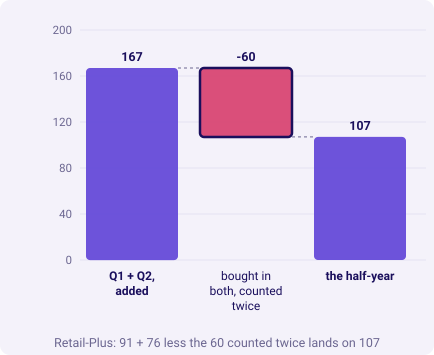

segment,Q1 + Q2 - both,counted directly
Business,36 + 35 - 32 = 39,39
Retail-Core,102 + 96 - 67 = 131,131
Retail-Plus,91 + 76 - 60 = 107,107
Student,15 + 20 - 11 = 24,24


In [12]:
both = {r["segment"]: int(r["bought_in_both"]) for r in run("c5_overlap", "Customers who bought in both quarters")}
q = {(r["segment"], r["quarter"]): int(r["customers"]) for r in per_q}
route2 = {s: q[(s, "Q1")] + q[(s, "Q2")] - both[s] for s in segs}
kit.bridge((f"Q1 + Q2, added", q[("Retail-Plus", "Q1")] + q[("Retail-Plus", "Q2")]),
           [("bought in both, counted twice", -both["Retail-Plus"])], end_label="the half-year",
           fmt=lambda v: f"{v:,.0f}", lit=(0,),
           title="Retail-Plus: 91 + 76 less the 60 counted twice lands on 107")
kit.table(["segment", "Q1 + Q2 - both", "counted directly"],
          [(s, f"{q[(s, 'Q1')]} + {q[(s, 'Q2')]} - {both[s]} = {route2[s]}", half[s]["customers"]) for s in segs],
          caption="The second route, every segment")

In [13]:
kit.check("the second route matches the direct count in every segment",
          all(route2[s] == half[s]["customers"] for s in segs))
kit.check("the customers counted twice are exactly the ones who bought in both quarters",
          all(added[s]["customers"] - half[s]["customers"] == both[s] for s in segs))

**What happened.** The answer is c: 60 Retail-Plus customers bought in both quarters, and 91 plus
76 less 60 is 107, the direct count. In every segment the customers counted twice are exactly
the customers who bought in both quarters, which is why the added line ran over.

> **Kavya's review.** Before you add a column, ask whether one customer can sit in two of its
> rows. Orders and rupees add. People add only across groups they cannot share, so a
> half-year of customers is counted from the orders, never added from the quarters.

### In the interview: what may you add, and what must an auditable query carry?

**[F] Why can you not add two quarters' customer counts to get the half-year's?** Because a
count of distinct customers is taken inside its own window, and a customer who bought in both
windows is in both counts. The half-year's customers equal Q1's plus Q2's less the customers in
both: for Retail-Plus 91 plus 76 less 60, which is 107, not 167. The same holds for daily users
added into a month. Orders and revenue add, because each order sits in one window.

**[D] A stakeholder's analyst must audit your query; what changes in how you write it, and what
would you refuse to compute in a notebook?** Each number gets a named step and a comment that
states its question and its definition, divisions are done in `numeric` and rounded on purpose,
every list is ordered on a unique key, and the suite carries its own tie-outs: segments against
the book, windows counted from the orders. The reported number is never computed on an export in
a notebook, because the analyst cannot rerun it on the book.

### Depth: can one query return the quarters and the half-year together?

`GROUP BY GROUPING SETS ((c.segment, o.quarter), (c.segment))` groups the orders twice in one
pass: once by segment and quarter, once by segment alone. Each count is taken from the orders
in its own set, so the half-year rows are counted, never added. A `NULL` in the quarter column
stands for the half-year row.

In [14]:
sets = run("c5_grouping_sets", "Quarters and half-year from one query", money=("revenue",))
half_rows = {r["segment"]: int(r["customers"]) for r in sets if r["quarter"] is None}
kit.check("the half-year rows from GROUPING SETS match the direct count",
          all(half_rows[s] == half[s]["customers"] for s in segs))

-- Depth: one query that returns every segment's quarter rows and its half-year row, each counted
-- from the orders. A NULL quarter stands for the half-year row.
SELECT c.segment,
       o.quarter,
       count(*)                      AS orders,
       count(DISTINCT o.customer_id) AS customers,
       sum(o.amount)                 AS revenue
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY GROUPING SETS ((c.segment, o.quarter), (c.segment))
ORDER  BY c.segment, o.quarter NULLS LAST;


segment,quarter,orders,customers,revenue
Business,Q1,97,36,"Rs 9,90,14,440"
Business,Q2,91,35,"Rs 9,75,84,600"
Business,NULL,188,39,"Rs 19,65,99,040"
Retail-Core,Q1,199,102,"Rs 3,73,070"
Retail-Core,Q2,193,96,"Rs 3,66,250"
Retail-Core,NULL,392,131,"Rs 7,39,320"
Retail-Plus,Q1,215,91,"Rs 5,85,770"
Retail-Plus,Q2,140,76,"Rs 4,13,380"
Retail-Plus,NULL,355,107,"Rs 9,99,150"
Student,Q1,27,15,"Rs 26,720"


## What did this chapter answer?

1. **How should the suite produce its half-year column?** Counted from the orders with the
   quarters' own definition, option B; `GROUPING SETS` returns every window in one query when
   Anand wants several.
2. **Do the segments add back to the book?** Yes, on orders, rupees and customers in each
   quarter: 538 orders, Rs 10,00,00,000 and 244 customers in Q1, because a customer belongs to
   one segment.
3. **How many Retail-Plus customers bought in the half-year?** 107, not the 167 that adding the
   quarters gives; the tier holds 120 members, and the book 301 customers, not 471.
4. **Does the overlap explain the gap?** Yes: 60 Retail-Plus customers bought in both quarters,
   and 91 plus 76 less 60 is 107; in every segment the double count equals the overlap.

Chapter 6 asks whether next Monday's run will give the analyst the same answers from the same
book.

In [15]:
kit.check_summary()